In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import emcee

from sbi.utils import BoxUniform
from sbi.inference import SNPE

c:\Users\Public\Anaconda\envs\MLproject\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# True parameters (change this)
c_true = 0.6   # intercept
m_true = 2  # slope
sigma = 0.3    # noise
num_points = 30

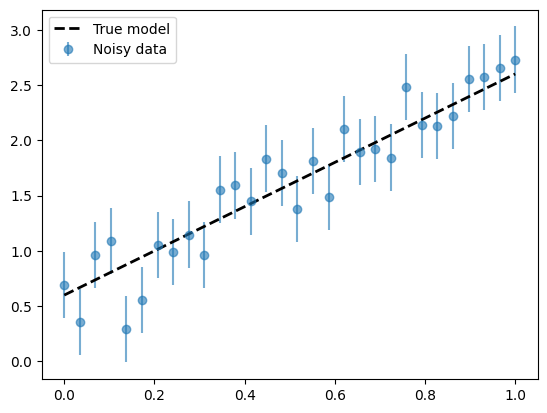

In [3]:
x = np.linspace(0.0, 1.0, num_points)
rng = np.random.default_rng(seed=42)
noise = rng.normal(0.0, sigma, size=num_points)

y_true = m_true * x + c_true
y_obs = m_true * x + c_true + noise

plt.figure()
plt.errorbar(x, y_obs, yerr=sigma, fmt="o", label="Noisy data", alpha=0.6)
plt.plot(x,y_true,c='black',linestyle='--',label="True model",linewidth=2)
plt.legend()
plt.show()

In [4]:
def log_prior(theta):
    """
    Prior over (c, m):
    c in [-1, 1], m in [-3, 3], uniform.
    """
    c, m = theta
    if -1.0 <= c <= 1.0 and -3.0 <= m <= 3.0:
        return 0.0
    else:
        return -np.inf 


def log_likelihood(theta, x, y, sigma):
    """
    Gaussian likelihood:
    y_i ~ N(m * x_i + c, sigma^2)
    """
    c, m = theta
    y_model = m * x + c
    residual = y - y_model
    # Sum of log N(residual_i | 0, sigma^2)
    const = -0.5 * len(y) * np.log(2.0 * np.pi * sigma**2)
    quad = -0.5 * np.sum((residual**2) / sigma**2)
    return const + quad


def log_posterior(theta, x, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, x, y, sigma)
    return lp + ll


def run_mcmc_emcee(x, y, sigma, nwalkers=32, nsteps=8000, burn_in=2000, seed=0):
    """
    Run emcee MCMC for parameters (c, m).
    Returns array of shape (n_post_samples, 2).
    """
    rng = np.random.default_rng(seed)
    ndim = 2

    # Initial positions for walkers (inside the prior box)
    initial_c = 0.0
    initial_m = 0.0
    initial_pos = np.array([initial_c, initial_m])

    # small random scatter around initial position
    pos = initial_pos + 1e-4 * rng.standard_normal(size=(nwalkers, ndim))

    sampler = emcee.EnsembleSampler(
        nwalkers,
        ndim,
        log_posterior,
        args=(x, y, sigma),
    )

    print("Running MCMC with emcee...")
    sampler.run_mcmc(pos, nsteps, progress=False)
    print("MCMC finished.")

    # Get chain: shape (nsteps, nwalkers, ndim)
    chain = sampler.get_chain()

    # Discard burn-in and flatten over walkers and steps
    samples = chain[burn_in:, :, :].reshape(-1, ndim)
    return samples

mcmc_samples = run_mcmc_emcee(x, y_obs, sigma)
print("MCMC samples shape:", mcmc_samples.shape)

Running MCMC with emcee...
MCMC finished.
MCMC samples shape: (192000, 2)


In [5]:
#  NPE with sbi (SNPE + normalizing flow)

torch.manual_seed(0)

# Prior over (c, m): c in [-1, 1], m in [-3, 3]
prior = BoxUniform(
    low=torch.tensor([-1.0, -3.0]),
    high=torch.tensor([1.0, 3.0])
)


def simulator(theta):
    """
    Simulator for sbi.
    Input:
        theta: tensor of shape (batch, 2) or (2,) with θ = (c, m)
    Output:
        y_sim: tensor of shape (batch, num_points)
    Model: y = m * x + c + noise
    """
    # Ensure 2D: (batch_size, 2)
    if theta.ndim == 1:
        theta = theta.unsqueeze(0)

    # θ = (c, m)
    c = theta[:, 0].unsqueeze(1)  # shape: (batch, 1)
    m = theta[:, 1].unsqueeze(1)  # shape: (batch, 1)

    # x-grid as torch, broadcast over batch
    x_torch = torch.linspace(0.0, 1.0, num_points).unsqueeze(0)  # (1, num_points)
    x_torch = x_torch.expand(theta.shape[0], -1)  # (batch, num_points)

    # Gaussian noise
    noise_torch = sigma * torch.randn_like(x_torch)

    # y = m * x + c + noise
    y_sim = m * x_torch + c + noise_torch  # (batch, num_points)
    return y_sim



In [6]:
# Generate simulations directly using prior.sample
num_simulations = 5000
print(f"Simulating {num_simulations} (theta, y) pairs for NPE training...")

theta_train = prior.sample((num_simulations,))  # shape (num_simulations, 2)
y_train = simulator(theta_train)               # shape (num_simulations, num_points)

print("Simulation for NPE done.")
print("theta_train shape:", theta_train.shape)
print("y_train shape:", y_train.shape)

# Set up NPE (SNPE) inference object
inference = SNPE(prior=prior)

# Append simulations and train the density estimator (a normalizing flow by default)

inference = inference.append_simulations(theta_train, y_train)
density_estimator = inference.train()
print("NPE training done.")

# Build posterior object from trained estimator
posterior = inference.build_posterior(density_estimator)



# Evaluate NPE posterior for the observed data y_obs


y_obs_torch = torch.tensor(y_obs, dtype=torch.float32)

num_posterior_samples = 20000
print(f"Sampling {num_posterior_samples} points from NPE posterior...")
with torch.no_grad():
    npe_samples_torch = posterior.sample((num_posterior_samples,), x=y_obs_torch)

npe_samples = npe_samples_torch.numpy()
print("NPE samples shape:", npe_samples.shape)


Simulating 5000 (theta, y) pairs for NPE training...
Simulation for NPE done.
theta_train shape: torch.Size([5000, 2])
y_train shape: torch.Size([5000, 30])
 Neural network successfully converged after 39 epochs.NPE training done.
Sampling 20000 points from NPE posterior...


20090it [00:00, 141207.45it/s]                           

NPE samples shape: (20000, 2)


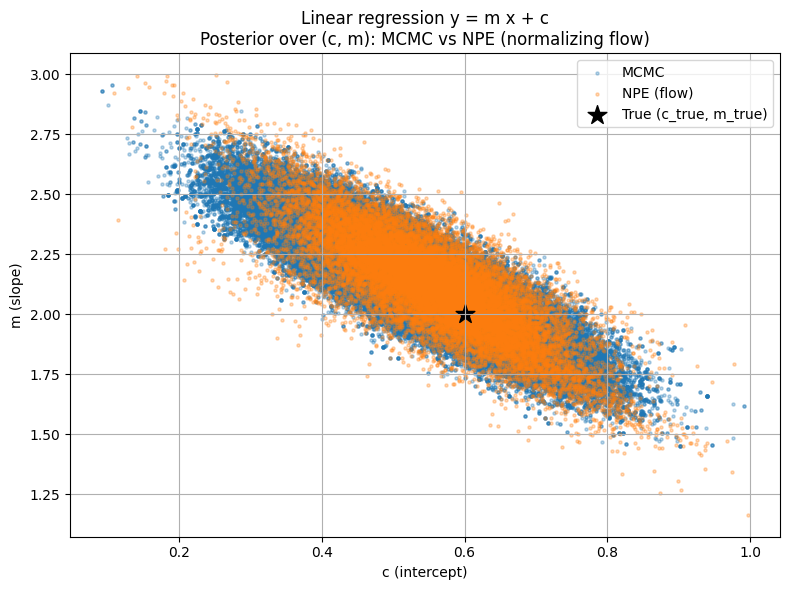

In [7]:
# Plot MCMC vs NPE vs true parameters

plt.figure(figsize=(8, 6))

# MCMC samples: parameters (c, m)
plt.scatter(
    mcmc_samples[:, 0], mcmc_samples[:, 1],
    s=5, alpha=0.3, label="MCMC", color="tab:blue"
)

# NPE samples: parameters (c, m)
plt.scatter(
    npe_samples[:, 0], npe_samples[:, 1],
    s=5, alpha=0.3, label="NPE (flow)", color="tab:orange"
)

# True parameters (c_true, m_true)
plt.scatter(
    [c_true], [m_true],
    marker="*", s=200, color="black", label="True (c_true, m_true)"
)

plt.xlabel("c (intercept)")
plt.ylabel("m (slope)")
plt.title("Linear regression y = m x + c\nPosterior over (c, m): MCMC vs NPE (normalizing flow)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Next Part MCMC vs SBI comparison

In [8]:
# True parameters (y = m_true * x + c_true + noise)
c_true = 0.3
m_true = 1.5
sigma_true = 0.3  # noise

num_points_raw = 30
x_raw = np.linspace(0.0, 1.0, num_points_raw)

rng = np.random.default_rng(seed=42)


def generate_observed_data():
    """
    Generate one observed dataset y_obs from the true line model.
    """
    noise = rng.normal(0.0, sigma_true, size=num_points_raw)
    y_obs = m_true * x_raw + c_true + noise
    return y_obs


In [9]:
# MCMC: prior, likelihood, posterior, and sampler


def log_prior(theta, prior_c, prior_m):
    """
    Uniform prior over c and m in given intervals.
    prior_c, prior_m are tuples (min, max).
    """
    c, m = theta
    if prior_c[0] <= c <= prior_c[1] and prior_m[0] <= m <= prior_m[1]:
        return 0.0  # constant log prior inside the box
    else:
        return -np.inf


def log_likelihood(theta, x, y, sigma):
    """
    Gaussian likelihood for y_i ~ N(m * x_i + c, sigma^2).
    """
    c, m = theta
    y_model = m * x + c
    residual = y - y_model
    const = -0.5 * len(y) * np.log(2.0 * np.pi * sigma**2)
    quad = -0.5 * np.sum((residual**2) / sigma**2)
    return const + quad


def log_posterior(theta, x, y, sigma, prior_c, prior_m):
    lp = log_prior(theta, prior_c, prior_m)
    if not np.isfinite(lp):
        return -np.inf
    ll = log_likelihood(theta, x, y, sigma)
    return lp + ll


def run_mcmc(x, y, sigma, prior_c, prior_m,
             nwalkers=32, nsteps=8000, burn_in=2000, seed=0):
    """
    Run emcee MCMC and return posterior samples for (c, m).
    """
    rng = np.random.default_rng(seed)
    ndim = 2

    # Initialise walkers around a point in the prior
    c0 = 0.0
    m0 = 0.0
    pos0 = np.array([c0, m0])
    pos = pos0 + 1e-4 * rng.standard_normal(size=(nwalkers, ndim))

    def _logpost(theta):
        return log_posterior(theta, x, y, sigma, prior_c, prior_m)

    sampler = emcee.EnsembleSampler(nwalkers, ndim, _logpost)

    sampler.run_mcmc(pos, nsteps, progress=False)
    chain = sampler.get_chain()

    samples = chain[burn_in:, :, :].reshape(-1, ndim)
    return samples

In [ ]:
# SBI / NPE setup


def build_prior_box(prior_c, prior_m):
    """
    Build a BoxUniform prior over (c, m) in the given ranges.
    """
    low = torch.tensor([prior_c[0], prior_m[0]], dtype=torch.float32)
    high = torch.tensor([prior_c[1], prior_m[1]], dtype=torch.float32)
    return BoxUniform(low=low, high=high)


def make_simulator(x_numpy, sigma_sim):
    """
    Create a simulator function for SBI that uses the given x-grid and noise sigma_sim.

    Simulator signature: simulator(theta_tensor) -> y_sim_tensor
    where theta_tensor is (batch, 2) containing (c, m).
    """
    x_torch = torch.tensor(x_numpy, dtype=torch.float32)

    def simulator(theta):
        # Ensure (batch, 2)
        if theta.ndim == 1:
            theta_batch = theta.unsqueeze(0)
        else:
            theta_batch = theta

        c = theta_batch[:, 0].unsqueeze(1)  # (batch, 1)
        m = theta_batch[:, 1].unsqueeze(1)  # (batch, 1)

        # Expand x_torch to (batch, num_points)
        x_batch = x_torch.unsqueeze(0).expand(theta_batch.shape[0], -1)

        noise = sigma_sim * torch.randn_like(x_batch)
        y_sim = m * x_batch + c + noise  # (batch, num_points)
        return y_sim

    return simulator


def run_sbi_npe(x_obs_numpy,
                prior_c, prior_m,
                num_simulations=5000,
                sigma_sim=None,
                seed=0):
    """
    Run SBI (SNPE) to approximate posterior over (c, m)
    given an observed data vector x_obs_numpy.

    Returns posterior samples as numpy array of shape (Nsamples, 2).
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

    if sigma_sim is None:
        sigma_sim = sigma_true  # default: same as true noise

    prior = build_prior_box(prior_c, prior_m)
    simulator = make_simulator(x_numpy=np.linspace(0.0, 1.0, len(x_obs_numpy)),
                               sigma_sim=sigma_sim)

    # Generate simulation data
    theta_train = prior.sample((num_simulations,))
    y_train = simulator(theta_train)

    # Build and train SNPE
    inference = SNPE(prior=prior)
    inference = inference.append_simulations(theta_train, y_train)
    density_estimator = inference.train()  # normalizing flow by default
    posterior = inference.build_posterior(density_estimator)

    # Sample from the learned posterior for the observed data
    y_obs_torch = torch.tensor(x_obs_numpy, dtype=torch.float32)
    with torch.no_grad():
        samples_torch = posterior.sample((10000,), x=y_obs_torch)

    return samples_torch.numpy()






### Group 1: Effect of number of simulations for SBI ###

=== Experiment: Raw data, num_simulations=1000 ===
Data length: 30
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 1000
 Neural network successfully converged after 111 epochs.

100%|██████████| 10000/10000 [00:00<00:00, 230029.07it/s]


MCMC mean (c, m): [0.23209997 1.64520969]
MCMC std  (c, m): [0.10756422 0.18342767]
SBI mean (c, m): [0.23665124 1.6805375 ]
SBI std  (c, m): [0.11777188 0.18893526]


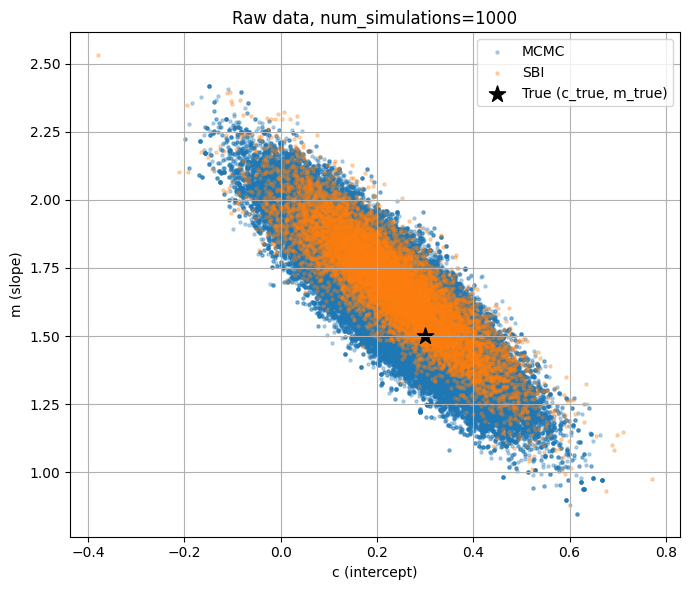


=== Experiment: Raw data, num_simulations=5000 ===
Data length: 30
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 5000
 Neural network successfully converged after 39 epochs.

100%|██████████| 10000/10000 [00:00<00:00, 180237.38it/s]

MCMC mean (c, m): [0.23197425 1.64554204]
MCMC std  (c, m): [0.10698863 0.18400347]
SBI mean (c, m): [0.24840483 1.6250484 ]
SBI std  (c, m): [0.10312173 0.19163854]


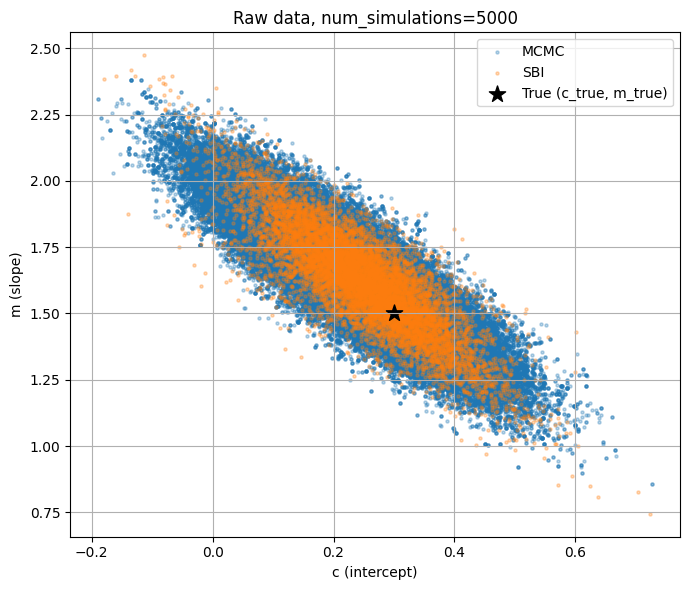


=== Experiment: Raw data, num_simulations=20000 ===
Data length: 30
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 20000
 Neural network successfully converged after 92 epochs.

100%|██████████| 10000/10000 [00:00<00:00, 207627.51it/s]


MCMC mean (c, m): [0.23197425 1.64554204]
MCMC std  (c, m): [0.10698863 0.18400347]
SBI mean (c, m): [0.2394935 1.6648033]
SBI std  (c, m): [0.10539123 0.18550684]


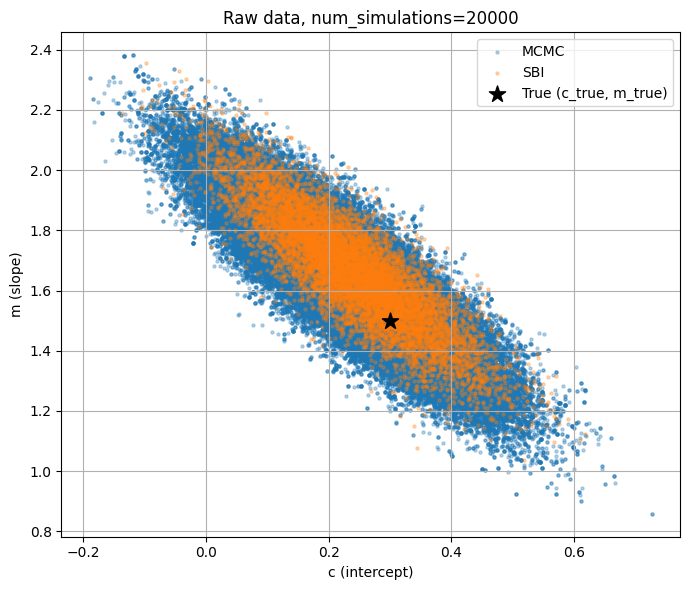



### Group 2: Effect of prior width ###

=== Experiment: Raw data, prior_c=(-1.0, 1.0), prior_m=(-3.0, 3.0), num_simulations=5000 ===
Data length: 30
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 5000
 Neural network successfully converged after 119 epochs.

10943it [00:00, 126056.05it/s]           


MCMC mean (c, m): [0.23099087 1.64915723]
MCMC std  (c, m): [0.10645854 0.18392927]
SBI mean (c, m): [0.08079225 1.8874078 ]
SBI std  (c, m): [0.41043442 0.60414463]


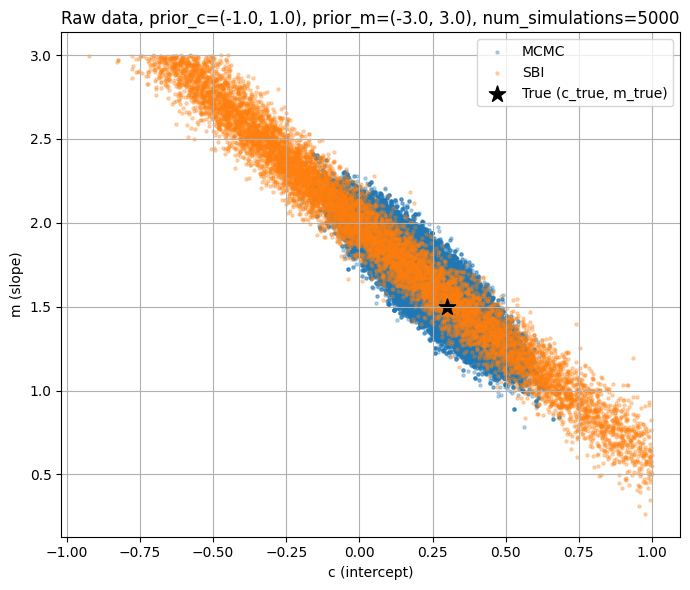


=== Experiment: Raw data, prior_c=(-3.0, 3.0), prior_m=(-6.0, 6.0), num_simulations=5000 ===
Data length: 30
Prior c: (-3.0, 3.0) Prior m: (-6.0, 6.0)
SBI simulations: 5000
 Neural network successfully converged after 130 epochs.

10724it [00:00, 148431.25it/s]           


MCMC mean (c, m): [0.23307268 1.64341327]
MCMC std  (c, m): [0.10716192 0.18374107]
SBI mean (c, m): [0.09556031 1.9209939 ]
SBI std  (c, m): [1.3773981 2.0609505]


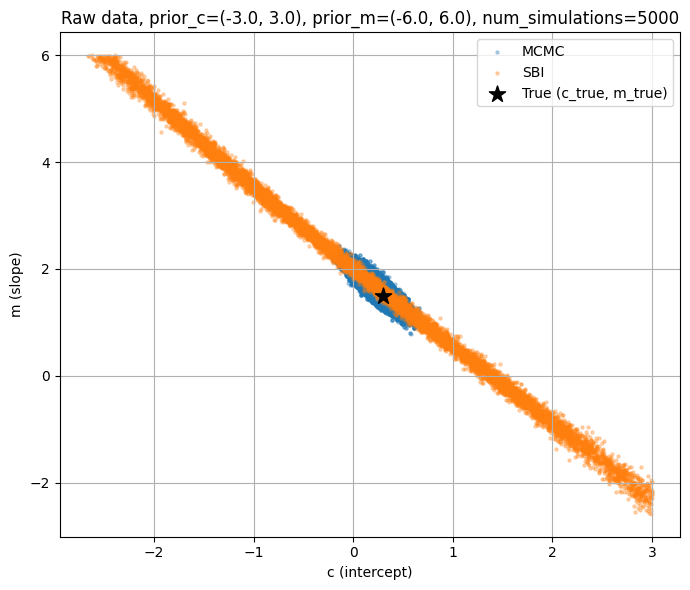


=== Experiment: Raw data, prior_c=(-10.0, 10.0), prior_m=(-20.0, 20.0), num_simulations=5000 ===
Data length: 30
Prior c: (-10.0, 10.0) Prior m: (-20.0, 20.0)
SBI simulations: 5000
 Neural network successfully converged after 212 epochs.

10501it [00:00, 148405.03it/s]           


MCMC mean (c, m): [0.23307268 1.64341327]
MCMC std  (c, m): [0.10716192 0.18374107]
SBI mean (c, m): [-0.11241243  2.3645446 ]
SBI std  (c, m): [4.83903   6.7140155]


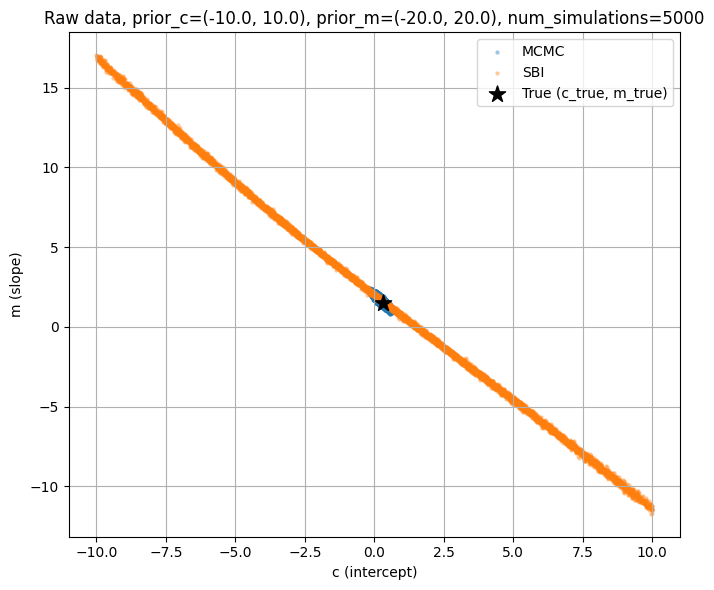



### Group 3: Effect of data representation (binning) ###

=== Experiment: Data representation: RAW (30 points), num_simulations=5000 ===
Data length: 30
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 5000
 Neural network successfully converged after 45 epochs.

100%|██████████| 10000/10000 [00:00<00:00, 146140.96it/s]


MCMC mean (c, m): [0.230636   1.64788283]
MCMC std  (c, m): [0.10799684 0.18592628]
SBI mean (c, m): [0.23934802 1.6280488 ]
SBI std  (c, m): [0.10388509 0.18089725]


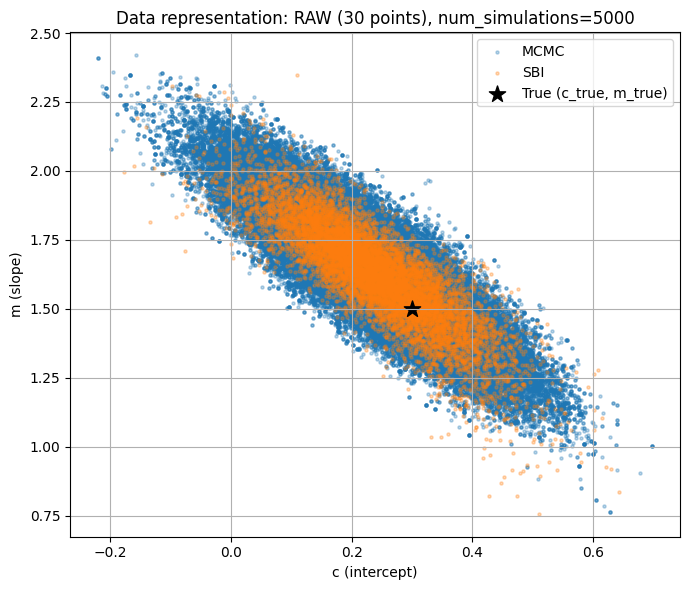


=== Experiment: Data representation: BINNED (10 bins), num_simulations=5000 ===
Data length: 10
Prior c: (-1.0, 1.0) Prior m: (-3.0, 3.0)
SBI simulations: 5000
 Neural network successfully converged after 57 epochs.

100%|██████████| 10000/10000 [00:00<00:00, 172827.72it/s]


MCMC mean (c, m): [0.23235675 1.64660249]
MCMC std  (c, m): [0.10838961 0.18602561]
SBI mean (c, m): [0.3029746 1.504725 ]
SBI std  (c, m): [0.09308518 0.17321166]


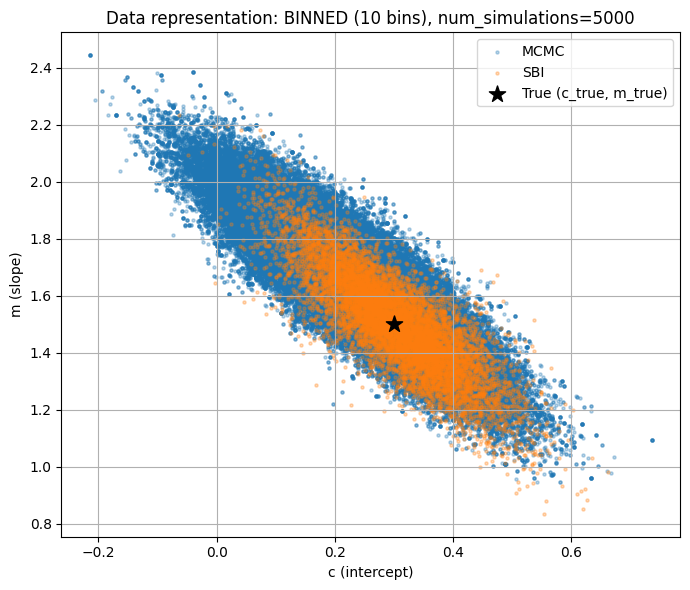

In [ ]:
# Data representations: raw vs binned


def bin_data(x, y, bin_size):
    """
    Bin data by averaging every 'bin_size' consecutive points.
    Returns x_binned (bin centres) and y_binned.

    Also returns the effective noise std for the binned data:
      sigma_binned = sigma_true / sqrt(bin_size)
    assuming independent Gaussian noise in raw y.
    """
    assert len(x) == len(y)
    N = len(x)
    assert N % bin_size == 0, "N must be divisible by bin_size for simple binning."

    nbins = N // bin_size
    x_binned = np.zeros(nbins)
    y_binned = np.zeros(nbins)

    for i in range(nbins):
        start = i * bin_size
        end = (i + 1) * bin_size
        x_binned[i] = np.mean(x[start:end])
        y_binned[i] = np.mean(y[start:end])

    sigma_binned = sigma_true / np.sqrt(bin_size)
    return x_binned, y_binned, sigma_binned





def compare_mcmc_sbi_single_case(
    description,
    x_data,
    y_obs_data,
    sigma_lik,
    prior_c,
    prior_m,
    num_simulations_sbi=5000,
    sbi_seed=0,
    mcmc_seed=0,
    show_plot=True
):
    """
    Run MCMC and SBI on a single configuration and make a comparison.
    """
    print("\n=== Experiment:", description, "===")
    print("Data length:", len(x_data))
    print("Prior c:", prior_c, "Prior m:", prior_m)
    print("SBI simulations:", num_simulations_sbi)

    # MCMC
    mcmc_samples = run_mcmc(
        x_data, y_obs_data, sigma_lik,
        prior_c, prior_m,
        nwalkers=32, nsteps=10000, burn_in=3000, seed=mcmc_seed
    )

    # SBI
    # For SBI, our simulator uses x in [0,1] with uniform spacing of the same length as y
    # The important part is that both MCMC and SBI see data of the same dimension.
    sbi_samples = run_sbi_npe(
        x_obs_numpy=y_obs_data,
        prior_c=prior_c,
        prior_m=prior_m,
        num_simulations=num_simulations_sbi,
        sigma_sim=sigma_lik,
        seed=sbi_seed
    )

    # Compute basic statistics
    def stats(samples, name):
        mean = samples.mean(axis=0)
        std = samples.std(axis=0)
        print(f"{name} mean (c, m): {mean}")
        print(f"{name} std  (c, m): {std}")
        return mean, std

    mcmc_mean, mcmc_std = stats(mcmc_samples, "MCMC")
    sbi_mean, sbi_std = stats(sbi_samples, "SBI")

    if show_plot:
        plt.figure(figsize=(7, 6))
        plt.scatter(
            mcmc_samples[:, 0], mcmc_samples[:, 1],
            s=5, alpha=0.3, label="MCMC", color="tab:blue"
        )
        plt.scatter(
            sbi_samples[:, 0], sbi_samples[:, 1],
            s=5, alpha=0.3, label="SBI", color="tab:orange"
        )
        plt.scatter(
            [c_true], [m_true],
            marker="*", s=150, color="black", label="True (c_true, m_true)"
        )
        plt.xlabel("c (intercept)")
        plt.ylabel("m (slope)")
        plt.title(description)
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()



# Main: run a set of experiments


def main():
    # Generate a single observed dataset using the true model
    y_obs_raw = generate_observed_data()


    #  1: vary simulations for SBI

    print("\n\n### Group 1: Effect of number of simulations for SBI ###")

    prior_c = (-1.0, 1.0)
    prior_m = (-3.0, 3.0)

    for num_sims in [1000, 5000, 20000]:
        desc = f"Raw data, num_simulations={num_sims}"
        compare_mcmc_sbi_single_case(
            description=desc,
            x_data=x_raw,
            y_obs_data=y_obs_raw,
            sigma_lik=sigma_true,
            prior_c=prior_c,
            prior_m=prior_m,
            num_simulations_sbi=num_sims,
            sbi_seed=0,
            mcmc_seed=0,
            show_plot=True
        )


    # 2: vary prior width

    print("\n\n### Group 2: Effect of prior width ###")

    prior_settings = [
        ((-1.0, 1.0), (-3.0, 3.0)),   # narrow
        ((-3.0, 3.0), (-6.0, 6.0)),   # medium
        ((-10.0, 10.0), (-20.0, 20.0))  # wide
    ]

    for prior_c, prior_m in prior_settings:
        desc = f"Raw data, prior_c={prior_c}, prior_m={prior_m}, num_simulations=5000"
        compare_mcmc_sbi_single_case(
            description=desc,
            x_data=x_raw,
            y_obs_data=y_obs_raw,
            sigma_lik=sigma_true,
            prior_c=prior_c,
            prior_m=prior_m,
            num_simulations_sbi=5000,
            sbi_seed=1,
            mcmc_seed=1,
            show_plot=True
        )



    # 3: data representation (binning)

    print("\n\n### Group 3: Effect of data representation (binning) ###")

    # Bin the raw data: e.g. 30 points -> 10 bins of 3 points each
    bin_size = 3
    x_binned, y_binned, sigma_binned = bin_data(x_raw, y_obs_raw, bin_size)

    # Keep the same prior as in group 1
    prior_c = (-1.0, 1.0)
    prior_m = (-3.0, 3.0)

    # Case A: raw data
    desc_raw = "Data representation: RAW (30 points), num_simulations=5000"
    compare_mcmc_sbi_single_case(
        description=desc_raw,
        x_data=x_raw,
        y_obs_data=y_obs_raw,
        sigma_lik=sigma_true,
        prior_c=prior_c,
        prior_m=prior_m,
        num_simulations_sbi=5000,
        sbi_seed=2,
        mcmc_seed=2,
        show_plot=True
    )

    # Case B: binned data  #Uses bin_data to convert the 30 raw points into: 10 binned x-values,10 binned y-values

    desc_binned = "Data representation: BINNED (10 bins), num_simulations=5000"
    compare_mcmc_sbi_single_case(
        description=desc_binned,
        x_data=x_binned,
        y_obs_data=y_binned,
        sigma_lik=sigma_binned,  # adjusted noise
        prior_c=prior_c,
        prior_m=prior_m,
        num_simulations_sbi=5000,
        sbi_seed=3,
        mcmc_seed=3,
        show_plot=True
    )


if __name__ == "__main__":
    main()